# 01 — Architecture tour

A guided walk through **intraday-ml-signals**: what each stage does, why it's built
that way, and a hands-on look at the actual components running over real recorded
market data.

## The big picture

```
Alpaca WS ──> IngestStage ──> SymbolPipeline ──> SignalPolicy ──> PositionBook/Risk ──> PaperExecutor
 (quotes)     (ring buffers)   │ per quote:        (threshold)      (long-only,          (market orders,
                               │ 1. resolve old                      breaker, caps)       paper only)
                               │    predictions → learn
                               │ 2. features → predict
                               └──────────── everything tapped ──> ColdStore (DuckDB)
```

Two hard rules shape everything:

| | Hot path (live decision loop) | Cold path (offline) |
|---|---|---|
| code | `src/signals/` | `scripts/`, these notebooks |
| pandas | **forbidden** (test-enforced) | fine — we use it below |
| compute | O(1) per event, ~10–80µs | whatever |
| storage | in-memory ring buffers | DuckDB |

Why: at ~6 quotes/second a pandas `DataFrame.append`-and-recompute loop would be
thousands of times slower and garbage-collect at the worst moments. Every feature
updates incrementally; nothing ever recomputes over a window.

**This notebook is cold path** — pandas/matplotlib everywhere, no apologies.

In [1]:
from pathlib import Path
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
DB = ROOT / "data" / "session.duckdb"
assert DB.exists(), "record a session first: python scripts/record.py --duration 1800"

conn = duckdb.connect(str(DB), read_only=True)
quotes = conn.execute("SELECT * FROM quotes WHERE symbol='BTC/USD' ORDER BY ts_ns").df()
trades = conn.execute("SELECT * FROM trades WHERE symbol='BTC/USD' ORDER BY ts_ns").df()
conn.close()
span_min = (quotes.ts_ns.max() - quotes.ts_ns.min()) / 60e9
print(f"{len(quotes)} quotes, {len(trades)} trades over {span_min:.1f} minutes")
quotes.head(3)

4049 quotes, 28 trades over 29.9 minutes


,symbol,ts_ns,bid,ask,bid_size,ask_size,recv_ns
0,BTC/USD,1783007108381978156,61603.17,61703.601,1.553670,0.77362,1783007108479108000
1,BTC/USD,1783007108382000486,61630.39,61703.601,0.780256,0.77362,1783007108479639000
2,BTC/USD,1783007108382072056,61630.39,61705.659,0.780256,1.55400,1783007108479723000


## 1. The data layer: quotes are the clock

A **quote** is the top of the order book: best bid (highest buyer) and best ask
(lowest seller). The **mid** `(bid+ask)/2` is our fair-value estimate — trades
bounce between bid and ask ("bid-ask bounce") and would feed the model pure noise.

Note the ratio above: this is the Phase 1 finding that shaped the whole design.
Alpaca's crypto feed only reports its own venue's trades (~2/min on BTC), while
quotes arrive ~6/second. So **features and prediction targets are built on quote
mids**, and trades only contribute a signed-flow feature.

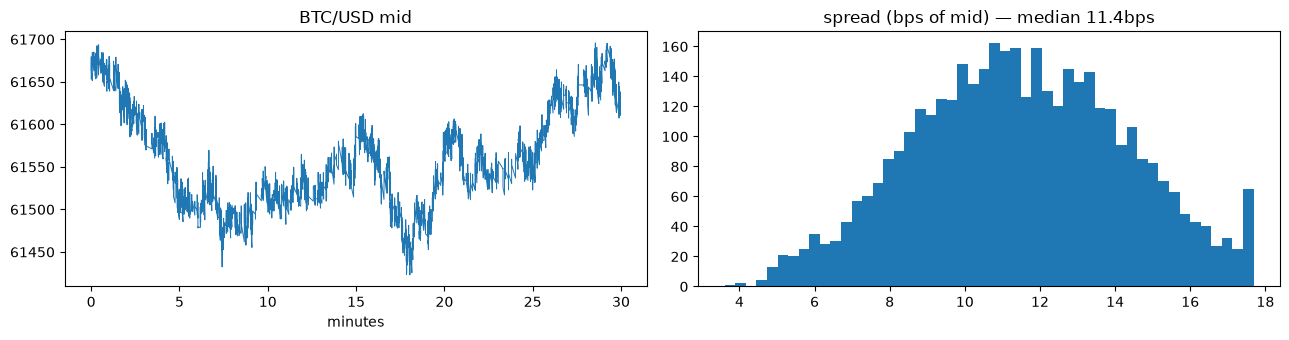

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.5))
t_min = (quotes.ts_ns - quotes.ts_ns.min()) / 60e9
mid = (quotes.bid + quotes.ask) / 2
ax1.plot(t_min, mid, lw=0.7); ax1.set_title("BTC/USD mid"); ax1.set_xlabel("minutes")
spread_bps = (quotes.ask - quotes.bid) / mid * 1e4
ax2.hist(spread_bps.clip(0, spread_bps.quantile(0.99)), bins=50)
ax2.set_title(f"spread (bps of mid) — median {spread_bps.median():.1f}bps")
plt.tight_layout()

## 2. Ring buffers: fixed memory, O(1) updates

The hot path never grows a list. `RingBuffer` is a **preallocated numpy array**
written in a circle — push is O(1) forever, and reading the last N never allocates
history.

One hard-won detail: **timestamps must be `int64`**. Epoch-nanoseconds (~1.7e18)
exceed float64's 2⁵³ integer precision — a float ring would silently corrupt them.

In [3]:
import sys
sys.path.insert(0, str(ROOT / "src"))
from signals.data.ringbuffer import RingBuffer

rb = RingBuffer(capacity=5)
for v in [1, 2, 3, 4, 5, 6, 7]:          # 7 pushes into capacity 5 -> wraps
    rb.push(float(v))
print("last 5 (oldest first):", rb.last(5))

ts = RingBuffer(4, dtype=np.int64)
ts.push(1_751_450_000_123_456_789)         # epoch ns
print("int64 ring preserves ns exactly:", ts.latest() == 1_751_450_000_123_456_789)
print("float64 would round it to      :", float(np.float64(1_751_450_000_123_456_789)))

last 5 (oldest first): [3. 4. 5. 6. 7.]
int64 ring preserves ns exactly: True
float64 would round it to      : 1.7514500001234568e+18


## 3. The feature engine

Every quote updates ~11 features, each in O(1), each **z-normalized online**
(running mean/std — never "fit" on a training set, so live and replay normalize
identically). The interesting ones:

| feature | what it captures |
|---|---|
| `ret_1..8` | momentum over the last k mid-changes |
| `vol` | rolling std of 1-lag returns (Welford, O(1) remove) |
| `spread_bps` | how expensive it is to trade right now |
| `imbalance` | (bid_size − ask_size)/(total) — book pressure |
| **`micro_bps`** | microprice offset: the size-*weighted* quote lean |
| `uptick` | EMA of mid-change signs — direction persistence |
| `flow` | EMA of signed trade sizes — aggressor pressure |

**Microprice** deserves a note: if there's 3 BTC bid but only 1 BTC offered, fair
value probably sits closer to the ask than the mid — buyers are queueing. It's the
classic short-horizon predictor from market-microstructure literature.

In [4]:
from signals.data.schema import Quote
from signals.features.engine import FeatureEngine

engine = FeatureEngine()
rows = []
for q in quotes.itertuples():
    vec = engine.update(Quote(q.symbol, int(q.ts_ns), q.bid, q.ask, q.bid_size, q.ask_size))
    if vec is not None:
        rows.append({"ts_ns": q.ts_ns, **engine.last_raw})   # raw (pre-z) for readability
feats = pd.DataFrame(rows)
print(f"{len(feats)} feature vectors (warmup ate the first ~64 quotes)")
feats[["ret_1", "vol", "spread_bps", "imbalance", "micro_bps", "uptick"]].describe().round(6)

3986 feature vectors (warmup ate the first ~64 quotes)


,ret_1,vol,spread_bps,imbalance,micro_bps,uptick
count,3986.000000,3986.000000,3986.000000,3986.000000,3986.000000,3986.000000
mean,-0.000000,0.000196,11.468762,0.015004,0.093272,-0.002846
std,0.000198,0.000018,2.819246,0.234579,1.541319,0.117763
min,-0.000458,0.000149,3.606504,-0.341604,-3.194341,-0.438313
25%,-0.000153,0.000184,9.446876,-0.006828,-0.033998,-0.090090
50%,0.000000,0.000196,11.416647,0.000261,0.001349,-0.001931
75%,0.000151,0.000210,13.481774,0.328127,1.573051,0.082165
max,0.000453,0.000250,18.880288,0.500290,3.128207,0.399049


## 4. Does the book lean actually predict anything?

Quick offline peek (this is research, so pandas is allowed): bucket quotes by
microprice offset, look at the average mid move over the next 10 seconds.

In [5]:
feats["mid"] = (quotes.set_index("ts_ns").loc[feats.ts_ns, "bid"].values
                 + quotes.set_index("ts_ns").loc[feats.ts_ns, "ask"].values) / 2
# forward 10s return: first mid at least 10s ahead (same rule as the live LabelQueue)
idx = np.searchsorted(feats.ts_ns.values, feats.ts_ns.values + 10_000_000_000)
ok = idx < len(feats)
fwd = pd.Series(np.where(ok, feats.mid.values[np.clip(idx, 0, len(feats)-1)] / feats.mid.values - 1, np.nan))
buckets = pd.qcut(feats.micro_bps, 5, duplicates="drop")
table = fwd.groupby(buckets, observed=True).agg(["mean", "count"])
table["mean_bps"] = table["mean"] * 1e4
print(table[["mean_bps", "count"]].round(3))
print("\nIf mean_bps rises across buckets, book lean carries forward information.")

                    mean_bps  count
micro_bps                          
(-3.195, -1.692]      -3.350    792
(-1.692, -0.00801]    -1.758    796
(-0.00801, 0.0137]    -1.759    793
(0.0137, 1.866]       -1.290    790
(1.866, 3.128]        -0.147    791

If mean_bps rises across buckets, book lean carries forward information.


## 5. Where everything lives

| path | stage |
|---|---|
| `src/signals/data/alpaca.py` | WebSocket adapter (auth, reconnect, ns-timestamp parsing) |
| `src/signals/data/ringbuffer.py` | the buffers above |
| `src/signals/features/` | online stats + the engine above |
| `src/signals/model/` | River model wrapper + no-lookahead label queue → **notebook 02** |
| `src/signals/core.py` | `SymbolPipeline` — the heart, shared by live & replay |
| `src/signals/signal/`, `execution/` | threshold policy, risk limits, paper orders |
| `src/signals/evaluation.py` | walk-forward scoring + trade sim → **notebook 03** |

Next: [02_online_learning_and_labels](02_online_learning_and_labels.ipynb) — how the
model learns without ever peeking at the future.